In [5]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from bloch_schrodinger.potential import Potential, create_parameter
from BECs.groundstate import normalize
from BECs.ssfm import SSFM
from BECs.ufuncs import gaussian2D
from numpy.random import standard_normal


lx, ly = 100,100
nres = 9

plane = Potential(
    [[lx,0],[0,ly]],
    (2**nres, 2**nres),
    v0 = 0
)

k = 3
sig = 9
psi0 = gaussian2D(plane.x, plane.y, lx/5, 0, sig, sig, 1) * np.exp(1j * k * plane.x) + standard_normal((2**nres, 2**nres))*1e-2
psi0 += gaussian2D(plane.x, plane.y, -lx/5, 0, sig, sig, 1) * np.exp(1j * -k * plane.x) + standard_normal((2**nres, 2**nres))*1e-2
psi0 = normalize(psi0, 1000**0.5 * 2)


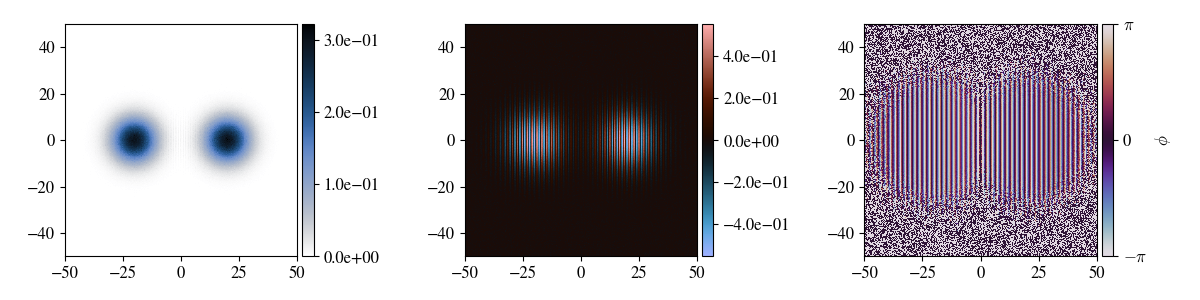

In [6]:
%matplotlib widget
from bloch_schrodinger.plotting import plot_cuts, plot_eigenvector, get_template

fig, axes = plot_eigenvector(
    [[abs(psi0.squeeze())**2, psi0.squeeze().real, xr.ufuncs.angle(psi0.squeeze())]],
    [[plane, plane, plane]],
    [['amplitude', 'real', 'phase']]
)
plt.show()

In [ ]:
g = create_parameter('g', np.linspace(0.2,3,10))

solv = SSFM(
    plane,
    psi0,
    g
)

solv.add_losses(0.15, 5)

ti, tf = 0, 15
samples = create_parameter('t', np.linspace(ti,tf,200))

psi = solv.solve(
    ti, tf, samples, verbose = True, parallelize = True, n_cores = 9
)

[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   1 tasks      | elapsed:  1.8min
[Parallel(n_jobs=9)]: Done   2 out of  10 | elapsed:  1.9min remaining:  7.7min
[Parallel(n_jobs=9)]: Done   3 out of  10 | elapsed:  2.1min remaining:  4.8min
[Parallel(n_jobs=9)]: Done   4 out of  10 | elapsed:  2.2min remaining:  3.2min
[Parallel(n_jobs=9)]: Done   5 out of  10 | elapsed:  2.3min remaining:  2.3min
[Parallel(n_jobs=9)]: Done   6 out of  10 | elapsed:  2.3min remaining:  1.6min
[Parallel(n_jobs=9)]: Done   7 out of  10 | elapsed:  2.4min remaining:  1.0min
[Parallel(n_jobs=9)]: Done   8 out of  10 | elapsed:  2.4min remaining:   36.1s
[Parallel(n_jobs=9)]: Done  10 out of  10 | elapsed:  3.2min finished


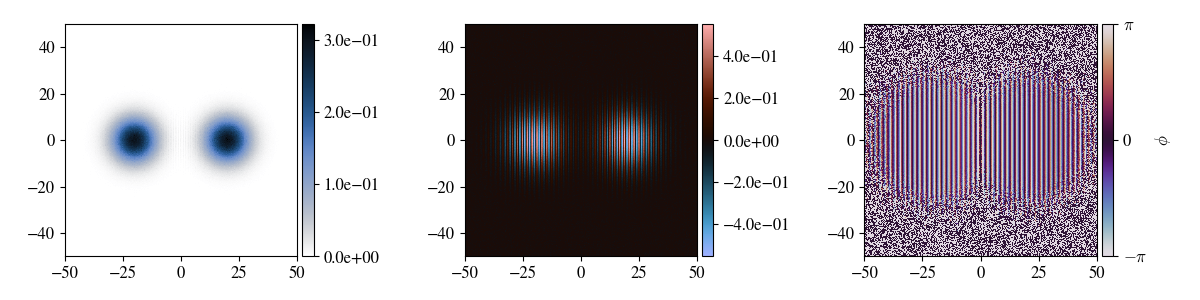

In [8]:
tp = psi
fig, axes = plot_eigenvector(
    [[abs(tp.squeeze())**2, tp.squeeze().real, xr.ufuncs.angle(tp.squeeze())]],
    [[plane, plane, plane]],
    [['amplitude', 'real', 'phase']]
)
plt.show()